In [1]:
from getpass import getpass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import snowflake.connector

from IPython.display import display

# Exploration thresholds, not statistical significance rules.
MIN_VIEWED_JOURNEYS = 100
MIN_CART_JOURNEYS = 30
TOP_N = 15

pd.set_option("display.max_columns", None)

In [2]:
query = """
SELECT
    item_id,
    SUM(viewed_session_product_count) AS viewed_journeys,
    SUM(cart_session_product_count) AS cart_journeys,
    SUM(purchased_session_product_count) AS purchased_journeys
FROM RETAILROCKET.ANALYTICS.MART_DAILY_PRODUCT_FUNNEL
GROUP BY item_id
ORDER BY item_id
"""

connection = snowflake.connector.connect(
    account="NXAUBQR-GS92621",
    user="VISHALMURLIKUMAR",
    password=getpass("Snowflake password: "),
    authenticator="username_password_mfa",
    role="SYSADMIN",
    warehouse="RETAILROCKET_WH",
    database="RETAILROCKET",
    schema="ANALYTICS",
)

try:
    with connection.cursor() as cursor:
        cursor.execute(query)

        products = pd.DataFrame(
            cursor.fetchall(),
            columns=[
                "item_id",
                "viewed_journeys",
                "cart_journeys",
                "purchased_journeys",
            ],
        )
finally:
    connection.close()

print("Product funnel data loaded. Connection closed.")

Product funnel data loaded. Connection closed.


In [3]:
count_columns = [
    "viewed_journeys",
    "cart_journeys",
    "purchased_journeys",
]

for column in ["item_id"] + count_columns:
    products[column] = pd.to_numeric(
        products[column], errors="raise"
    ).astype("int64")

assert not products.empty
assert products["item_id"].is_unique
assert products.notna().all().all()
assert (products["viewed_journeys"] > 0).all()
assert (products[count_columns] >= 0).all().all()

assert (
    products["cart_journeys"]
    <= products["viewed_journeys"]
).all()

assert (
    products["purchased_journeys"]
    <= products["cart_journeys"]
).all()

assert products["viewed_journeys"].sum() == 2_330_775
assert products["cart_journeys"].sum() == 45_114
assert products["purchased_journeys"].sum() == 14_807

print(f"Validated {len(products):,} viewed products.")
print("Product totals reconcile with the overall funnel.")

Validated 234,838 viewed products.
Product totals reconcile with the overall funnel.


In [4]:
products["product_label"] = (
    "Product " + products["item_id"].astype(str)
)

products["view_to_cart_pct"] = (
    100
    * products["cart_journeys"]
    / products["viewed_journeys"]
)

products["cart_to_purchase_pct"] = (
    100
    * products["purchased_journeys"]
    / products["cart_journeys"].replace(0, np.nan)
)

products["view_to_purchase_pct"] = (
    100
    * products["purchased_journeys"]
    / products["viewed_journeys"]
)

products["view_without_cart_journeys"] = (
    products["viewed_journeys"] - products["cart_journeys"]
)

products["cart_without_purchase_journeys"] = (
    products["cart_journeys"] - products["purchased_journeys"]
)

display(products.head().round(3))

,item_id,viewed_journeys,cart_journeys,purchased_journeys,product_label,view_to_cart_pct,cart_to_purchase_pct,view_to_purchase_pct,view_without_cart_journeys,cart_without_purchase_journeys
0,3,2,0,0,Product 3,0.0,NaN,0.0,2,0
1,4,3,0,0,Product 4,0.0,NaN,0.0,3,0
2,6,27,0,0,Product 6,0.0,NaN,0.0,27,0
3,9,2,0,0,Product 9,0.0,NaN,0.0,2,0
4,15,16,2,0,Product 15,12.5,0.0,0.0,14,2


In [5]:
total_views = int(products["viewed_journeys"].sum())
total_carts = int(products["cart_journeys"].sum())
total_purchases = int(products["purchased_journeys"].sum())

overall_view_to_cart = total_carts / total_views
overall_cart_to_purchase = total_purchases / total_carts
overall_view_to_purchase = total_purchases / total_views

overall = pd.DataFrame({
    "viewed_journeys": [total_views],
    "cart_journeys": [total_carts],
    "purchased_journeys": [total_purchases],
    "view_to_cart_pct": [100 * overall_view_to_cart],
    "cart_to_purchase_pct": [100 * overall_cart_to_purchase],
    "view_to_purchase_pct": [100 * overall_view_to_purchase],
})

display(overall.round(3))

,viewed_journeys,cart_journeys,purchased_journeys,view_to_cart_pct,cart_to_purchase_pct,view_to_purchase_pct
0,2330775,45114,14807,1.936,32.821,0.635


In [6]:
eligible = products.loc[
    products["viewed_journeys"] >= MIN_VIEWED_JOURNEYS
].copy()

# High-volume products below the overall view-to-cart benchmark.
view_cart_review = (
    eligible.loc[
        eligible["view_to_cart_pct"]
        < 100 * overall_view_to_cart
    ]
    .sort_values(
        ["viewed_journeys", "view_to_cart_pct"],
        ascending=[False, True],
    )
    .head(TOP_N)
)

# Products with enough cart activity but lower purchase progression.
cart_purchase_review = (
    eligible.loc[
        (eligible["cart_journeys"] >= MIN_CART_JOURNEYS)
        & (
            eligible["cart_to_purchase_pct"]
            < 100 * overall_cart_to_purchase
        )
    ]
    .sort_values(
        ["cart_journeys", "cart_to_purchase_pct"],
        ascending=[False, True],
    )
    .head(TOP_N)
)

# Highest observed purchase rates among products meeting the threshold.
highest_observed_rates = (
    eligible.sort_values(
        ["view_to_purchase_pct", "viewed_journeys"],
        ascending=[False, False],
    )
    .head(TOP_N)
)

columns = [
    "item_id",
    "viewed_journeys",
    "cart_journeys",
    "purchased_journeys",
    "view_to_cart_pct",
    "cart_to_purchase_pct",
    "view_to_purchase_pct",
]

print(
    f"Products with at least {MIN_VIEWED_JOURNEYS} "
    f"viewed journeys: {len(eligible):,}"
)

print("\nHigh-volume view-to-cart investigation list")
display(view_cart_review[columns].round(3))

print("\nCart-to-purchase investigation list")
display(cart_purchase_review[columns].round(3))

print("\nHighest observed view-to-purchase rates")
display(highest_observed_rates[columns].round(3))

Products with at least 100 viewed journeys: 3,105

High-volume view-to-cart investigation list


,item_id,viewed_journeys,cart_journeys,purchased_journeys,view_to_cart_pct,cart_to_purchase_pct,view_to_purchase_pct
94618,187946,3099,0,0,0.000,NaN,0.000
2717,5411,2153,8,0,0.372,0.000,0.000
186535,370653,1743,0,0,0.000,NaN,0.000
110421,219512,1463,28,7,1.914,25.000,0.478
150000,298009,1449,0,0,0.000,NaN,0.000
48965,96924,1434,0,0,0.000,NaN,0.000
169097,335975,1268,0,0,0.000,NaN,0.000
76347,151444,1150,0,0,0.000,NaN,0.000
71861,142466,977,1,0,0.102,0.000,0.000
218731,434782,964,0,0,0.000,NaN,0.000



Cart-to-purchase investigation list


,item_id,viewed_journeys,cart_journeys,purchased_journeys,view_to_cart_pct,cart_to_purchase_pct,view_to_purchase_pct
157333,312728,771,132,24,17.121,18.182,3.113
206274,409804,529,127,27,24.008,21.260,5.104
14689,29196,757,102,13,13.474,12.745,1.717
161074,320130,1052,85,26,8.080,30.588,2.471
129372,257040,1202,67,17,5.574,25.373,1.414
23383,46232,519,55,13,10.597,23.636,2.505
170971,339703,525,48,5,9.143,10.417,0.952
158769,315543,744,42,12,5.645,28.571,1.613
155865,309778,1220,41,10,3.361,24.390,0.820
117835,234255,1053,38,10,3.609,26.316,0.950



Highest observed view-to-purchase rates


,item_id,viewed_journeys,cart_journeys,purchased_journeys,view_to_cart_pct,cart_to_purchase_pct,view_to_purchase_pct
192720,382885,161,20,15,12.422,75.000,9.317
209400,416017,270,41,25,15.185,60.976,9.259
97380,193518,115,17,10,14.783,58.824,8.696
231699,460553,153,14,12,9.150,85.714,7.843
152113,302307,104,12,8,11.538,66.667,7.692
23345,46156,358,45,26,12.570,57.778,7.263
109470,217605,180,21,13,11.667,61.905,7.222
200878,399192,100,10,7,10.000,70.000,7.000
88808,176484,116,17,8,14.655,47.059,6.897
103738,206241,102,11,7,10.784,63.636,6.863


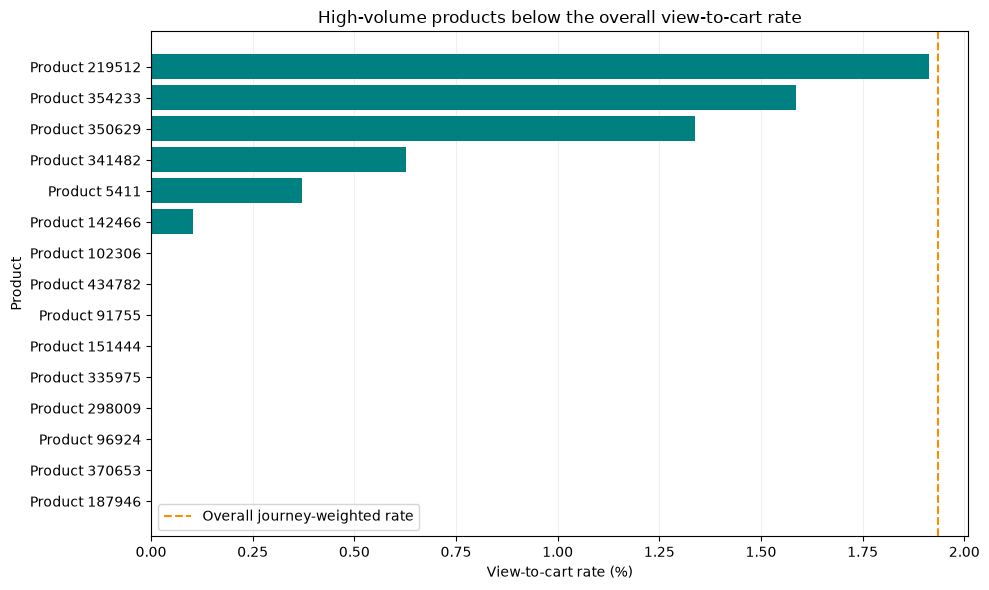

In [7]:
if view_cart_review.empty:
    print("No products meet the view-to-cart review criteria.")
else:
    chart_data = view_cart_review.sort_values(
        "view_to_cart_pct"
    )

    fig, ax = plt.subplots(figsize=(10, 6))

    ax.barh(
        chart_data["product_label"],
        chart_data["view_to_cart_pct"],
        color="teal",
    )

    ax.axvline(
        100 * overall_view_to_cart,
        color="darkorange",
        linestyle="--",
        label="Overall journey-weighted rate",
    )

    ax.set_title(
        "High-volume products below the overall view-to-cart rate"
    )
    ax.set_xlabel("View-to-cart rate (%)")
    ax.set_ylabel("Product")
    ax.legend()
    ax.grid(axis="x", alpha=0.2)
    ax.set_axisbelow(True)

    fig.tight_layout()
    plt.show()

In [8]:
threshold_summary = []

for threshold in [50, 100, 250, 500]:
    subset = products.loc[
        products["viewed_journeys"] >= threshold
    ]

    views = int(subset["viewed_journeys"].sum())
    purchases = int(subset["purchased_journeys"].sum())

    threshold_summary.append({
        "minimum_viewed_journeys": threshold,
        "eligible_products": len(subset),
        "share_of_all_viewed_journeys_pct": (
            100 * views / total_views
        ),
        "eligible_view_to_purchase_pct": (
            100 * purchases / views if views else np.nan
        ),
    })

display(pd.DataFrame(threshold_summary).round(3))

,minimum_viewed_journeys,eligible_products,share_of_all_viewed_journeys_pct,eligible_view_to_purchase_pct
0,50,8797,42.178,0.828
1,100,3105,25.529,0.836
2,250,516,9.332,0.876
3,500,99,3.411,0.961
